# Exploratory Data Analysis (EDA) on Retail Sales Dataset

## Objective

The objective of this project is to analyze retail sales data using Python. The analysis focuses on understanding customer behavior, sales trends, product performance, and business insights through statistical analysis and data visualization.

This project uses the following Python libraries:
- Pandas
- NumPy
- Matplotlib
- Seaborn

The insights obtained from this analysis can help businesses improve decision-making and increase sales.

### Step 1: Import Libraries
Why?

Before working with data, we need Python libraries.

Pandas → Read and analyze datasets.
NumPy → Mathematical calculations.
Matplotlib → Basic graphs.
Seaborn → Beautiful statistical graphs.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

# Improve graph appearance
plt.style.use("ggplot")
sns.set_palette("Set2")

### Step 2: Load Dataset
Why?
The dataset is stored as a CSV file. We use Pandas to load it.

In [25]:
df = pd.read_csv("retail_sales_data.csv")

### Step 3: Display First Five Records
Why?
This helps us understand the structure of the dataset.

In [26]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Groceries,3,50,150
1,2,2023-02-27,CUST002,Female,26,Beauty,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Footwear,1,30,30
3,4,2023-05-21,CUST004,Male,37,Toys,1,500,500
4,5,2023-05-06,CUST005,Male,30,Toys,2,50,100


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [27]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Pet Supplies,1,50,50
996,997,2023-11-17,CUST997,Male,52,Furniture,3,30,90
997,998,2023-10-29,CUST998,Female,23,Music,4,25,100
998,999,2023-12-05,CUST999,Female,36,Footwear,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Beauty,4,30,120


#### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [28]:
df.shape

(1000, 9)

#### Observation:
The dataset contains 1000 records and 9 columns.
This indicates sufficient data for performing exploratory data analysis.

### Step 6: Column Names

In [29]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

#### Observation:
The dataset contains customer information, product details,
transaction date, quantity purchased, unit price, and total sales amount.

### Step 7: Dataset Information

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


#### Observation
- The dataset contains 1000 rows and 9 columns.
- There are no missing values in any column.
- The dataset contains both numerical and categorical variables.
- The `Date` column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 8: Check Missing Values

In [31]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

#### Observation
The dataset does not contain any missing values in any column. Therefore, no data cleaning or imputation is required before performing the analysis.

### Step 9: Descriptive Statistics

In [32]:
df.describe()

print("Mean")
print(df.mean(numeric_only=True))

print("Median")
print(df.median(numeric_only=True))

print("Mode")
print(df.mode())

print("Standard Deviation")
print(df.std(numeric_only=True))

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64
Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64
Mode
     Transaction ID        Date Customer ID  Gender   Age Product Category  \
0                 1  2023-05-16     CUST001  Female  43.0             Toys   
1                 2         NaN     CUST002     NaN  64.0              NaN   
2                 3         NaN     CUST003     NaN   NaN              NaN   
3                 4         NaN     CUST004     NaN   NaN              NaN   
4                 5         NaN     CUST005     NaN   NaN              NaN   
..              ...         ...         ...     ...   ...              ...   
995             996         NaN     CUST995     NaN   NaN              NaN   
996             997         NaN     CUST996     NaN   NaN              NaN   
9

#### Observation
The descriptive statistics provide an overview of the numerical variables in the dataset.
- The average customer age is approximately **41 years**.
- Customers purchase an average of **2.5 products** per transaction.
- The average price per unit is approximately **180**.
- The average transaction amount is approximately **456**.
- The standard deviation indicates that there is noticeable variation in customer purchases and transaction amounts.

### Step 10: Time series analysis

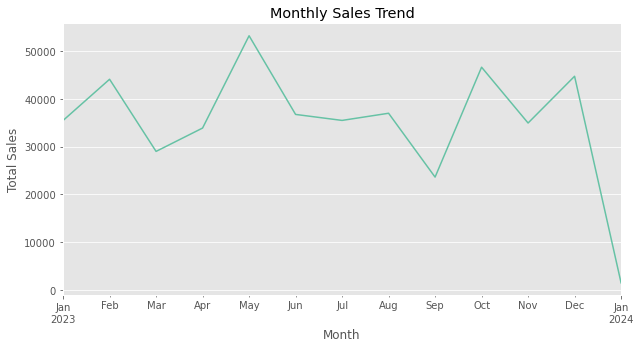

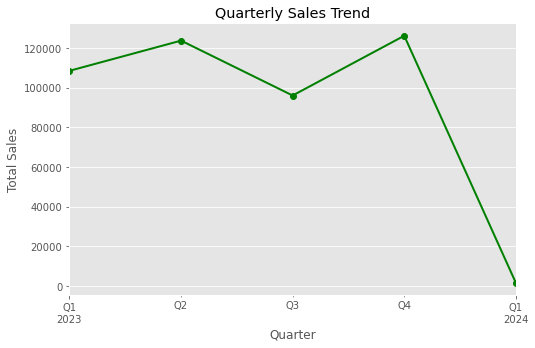

In [33]:
df["Date"] = pd.to_datetime(df["Date"])

# Monthly Sales Trend

monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

# Quarterly Sales Trend

quarterly_sales = df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"].sum()

plt.figure(figsize=(8,5))

quarterly_sales.plot(
    kind="line",
    marker="o",
    color="green",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

#### Observation
- Monthly sales fluctuate throughout the year.
- The highest sales were recorded in **May 2023**.
- The lowest sales appear in **January 2024**, but this is because the month contains incomplete data.
- Overall, sales remain relatively consistent with a few peak months, indicating seasonal variations in customer purchases.
- Quarterly sales provide a broader view of the overall business performance.
- Sales remained relatively stable across the quarters, with one quarter performing better than the others due to higher monthly sales.
- The final quarter may show slightly lower sales if the dataset contains incomplete records for the last month.
- Quarterly analysis helps identify seasonal trends and supports better business planning.

### Step 11: Customer demographics analysis 

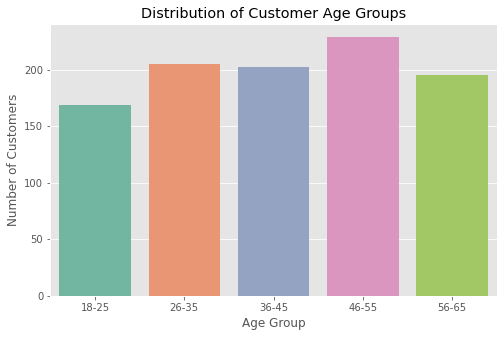

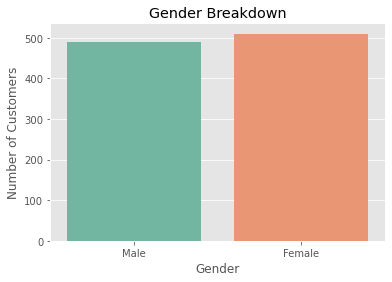

In [34]:
# Create Age Groups
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# Plot Age Group Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Age Group', data=df)

plt.title("Distribution of Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

# Gender Breakdown
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

#### Observation
- The chart shows the distribution of customers across different age groups.
- Customers in the **36–45 years** age group represent a significant portion of the customer base.
- The distribution indicates that middle-aged customers contribute considerably to retail sales.
- The dataset contains both male and female customers.
- The gender distribution is relatively balanced, indicating that customers from both genders actively purchase products.
- This suggests that marketing strategies can be designed to target both customer groups effectively.

### Step 12: Product analysis: 

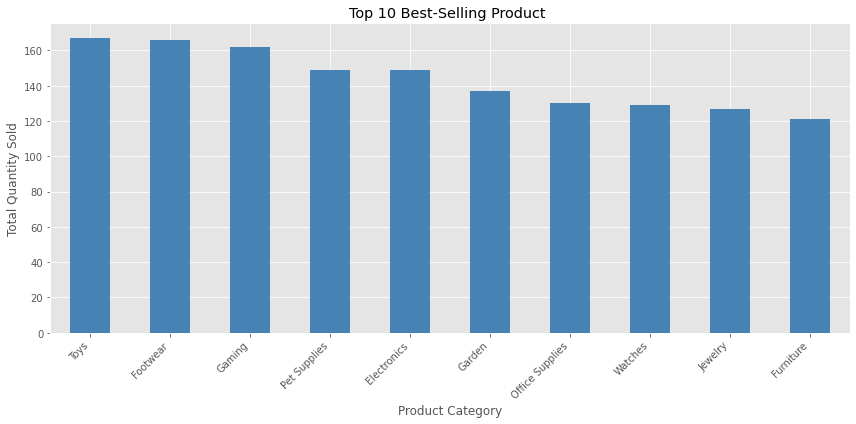

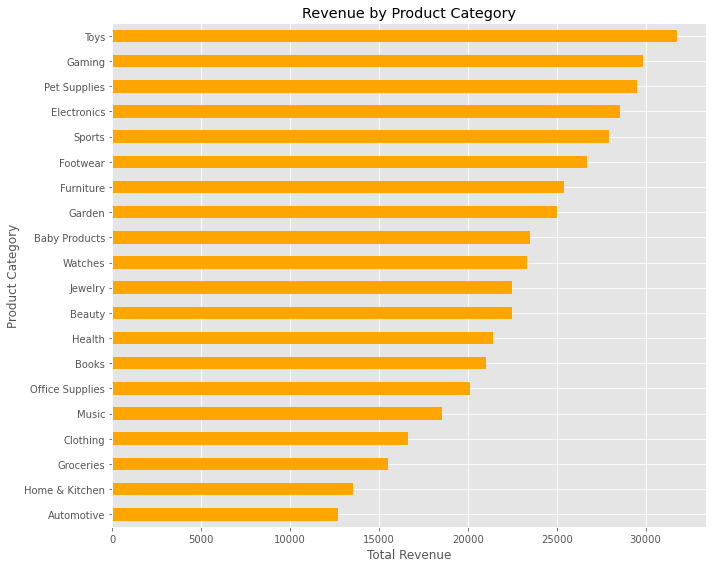

In [39]:
# Best-Selling Product 

top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar", color="steelblue")

plt.title("Top 10 Best-Selling Product ")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Revenue by Product Category
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values()

plt.figure(figsize=(10,8))

category_revenue.plot(kind="barh", color="orange")

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

#### Observation
- The chart displays the top 10 product categories based on the total quantity sold.
- The highest-selling category has the greatest customer demand and contributes the largest sales volume.
- Categories with lower quantities indicate comparatively lower customer demand and may require promotional strategies to increase sales.
- This analysis helps businesses prioritize inventory management and ensure adequate stock for high-demand product categories.
- The chart compares the total revenue generated by each product category.
- The highest-revenue category contributes the most to the overall business income.
- Some categories generate lower revenue despite being sold, indicating opportunities for pricing or marketing improvements.
- Revenue analysis helps businesses identify profitable categories and make informed decisions regarding inventory and promotional activities.

### Step 13:  Heatmap

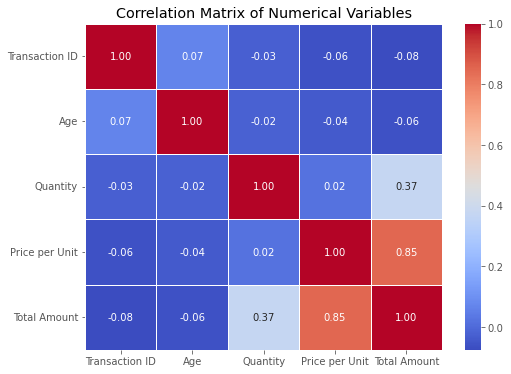

In [43]:
# Correlation Matrix

plt.figure(figsize=(8,6))

correlation = df[['Transaction ID','Age','Quantity','Price per Unit','Total Amount']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

#### Observation
- The correlation matrix shows the relationship between the numerical variables in the retail sales dataset.
- **Quantity** and **Total Amount** have a positive correlation, indicating that purchasing more items generally increases the total transaction value.
- **Price per Unit** also shows a positive relationship with **Total Amount**, as higher-priced products contribute to higher sales revenue.
- **Age** has a weak correlation with the other numerical variables, suggesting that customer age has little influence on purchase quantity or transaction value.
- Overall, the heatmap helps identify the strength and direction of relationships between numerical variables, supporting better business analysis and decision-making.

### Step 14: Average Spending

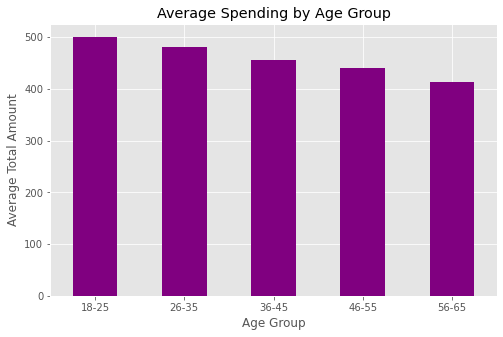

In [44]:
# Average Spending by Age Group

age_group_sales = df.groupby("Age Group")["Total Amount"].mean()

plt.figure(figsize=(8,5))

age_group_sales.plot(kind="bar", color="purple")

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Total Amount")

plt.xticks(rotation=0)
plt.show()

#### Observation

- The chart compares the average spending across different customer age groups.
- Although some age groups may have fewer customers, they can generate higher average transaction values.
- This insight suggests that customer spending behavior differs across age groups, not just the number of customers.
- Businesses can use this information to design age-specific marketing campaigns and personalized promotions.

### Step 15: Conclusion
Based on the exploratory data analysis of the retail sales dataset, the following business recommendations are suggested:
1. **Maintain sufficient inventory for high-performing product categories.**
   Product categories with the highest sales and revenue should be stocked adequately to prevent stock shortages and maximize customer satisfaction.
2. **Implement targeted marketing campaigns based on customer demographics.**
   Since spending patterns vary across different age groups and both genders contribute significantly to sales, personalized promotions can help increase customer engagement and revenue.
3. **Plan promotional offers during lower-sales periods.**
   Monthly and quarterly sales trends indicate fluctuations in customer demand. Offering discounts, seasonal promotions, or loyalty programs during slower periods can help improve overall sales performance.